# AAV9 — GT score study with the Potts-regression GT

Redoes `AAV9_fitting_protocol.ipynb`'s GT-score study (section 2b: deterministic GT score
distribution over the real library; sections 5-6: protocol-simulated log enrichment vs GT
score vs real target) with the GT source swapped: instead of the naive per-cell group-means
+ empirical-Bayes-shrunk `F_viab_GT`/`J_naive_final`, this notebook uses the joint
ridge-regularized Potts regression fit directly on `aav9.csv` in `AAV9_potts_regression.ipynb`
(`F_potts`/`J_potts`, loaded here via `lib/initialize_weights.load_F_viab_aav9_potts`/
`load_J_viab_aav9_potts`, not recomputed -- the ridge CV fit itself takes several minutes and
is already validated there).

Three things, as asked:
1. A few individual `J_potts[i, j]` position-pair couplings, shown directly (not surfaced
   anywhere else so far).
2. The distribution of the deterministic GT score (`compute_score(F_potts, J_potts)`, no
   protocol noise) across the real `aav9.csv` library.
3. The distribution of `target1` -- the log enrichment a *simulated* `Protocol` produces when
   seeded with this GT and run through one `loop_DE()` round, at the project's established
   baseline hyperparameters (`mu=50`, `T_viab=0.8`, `noise_viab=0.5`, `D=1e9`,
   `AAV9_fitting_protocol.ipynb` section 2) -- compared against both the GT score and the real
   `aav9.csv` target.

## 0. Setup

In [1]:
import sys, os

sys.path.insert(0, os.path.abspath("../../lib"))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from analysisV1 import AA_LABELS, pearson
from sequence_classesV1 import ProtocolV3
from initialize_weights import (
    load_F_viab_aav9_potts, load_J_viab_aav9_potts, NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

message = "AAV9 Potts-GT score study 1.0"


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Real AAV9 data

In [2]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
assert int(lengths[0]) == NUM_POSITIONS

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), NUM_POSITIONS)
target     = df["target"].to_numpy()

sequences = jnp.asarray(seq_matrix)
d0        = sequences.shape[0]

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"d0 = {d0:,} real AAV9 library sequences")


68,776 variants, columns: ['sequence', 'target', 'error']
seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
d0 = 68,776 real AAV9 library sequences


## 2. Potts-regression GT weights + baseline protocol config

`F_potts`/`J_potts` come from `AAV9_potts_regression.ipynb` (joint ridge regression fit
directly on this exact `aav9.csv`), loaded via `lib/initialize_weights.py`'s
`load_F_viab_aav9_potts`/`load_J_viab_aav9_potts` -- already in the right amino-acid/position
convention for `seq_matrix` above (same `build_J` convention as the naive GT).

`F_sel`/`J_sel` are zero, same reasoning as `AAV9_fitting_protocol.ipynb`: `loop_DE()`
computes `lambda0p`/`lambda2p` (-> `target1`, the viability log-enrichment) BEFORE
`selectivity()` runs, so `F_sel`/`J_sel` cannot influence anything plotted below.

Baseline config is the SAME project-established "best realistic" operating point used by
`AAV9_fitting_protocol.ipynb` (`mu_HEK_multiplicity_sweep.ipynb` / `T_viab_sweep.ipynb` /
`noise_viab_sweep.ipynb`): `mu=50`, `T_viab=0.8`, `noise_viab=0.5`, `D=1e9` -- kept identical
so the two GTs' resulting distributions are directly comparable, not confounded by a
different operating point.

In [3]:
F_potts = load_F_viab_aav9_potts()
J_potts = load_J_viab_aav9_potts()

F_sel = jnp.zeros_like(F_potts)
J_sel = jnp.zeros_like(J_potts)

RHO_REF          = 1e-3
MU_FIXED         = 50
T_VIAB_FIXED     = 1.3
NOISE_VIAB_FIXED = 0.5
D_FIXED          = 1e9
DILUTION_FACTOR  = 10
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1.0

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 150

protocol = ProtocolV3(multinomialNGS=True, N0=N0_FIXED, N1=N1_FIXED,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
        )

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")


mu = 50.00   N1=3.439e+09   N0=5.158e+11


### 2a. A few `J_potts` instances

Position-pair coupling-strength heatmap (mean `|J_ij(a, b)|` over the 21 position pairs)
first, to pick out which pairs actually carry the strongest coupling, then the raw
(amino acid x amino acid) heatmap for a handful of those pairs -- what an individual `J[i, j]`
slice actually looks like, not just its aggregate magnitude.

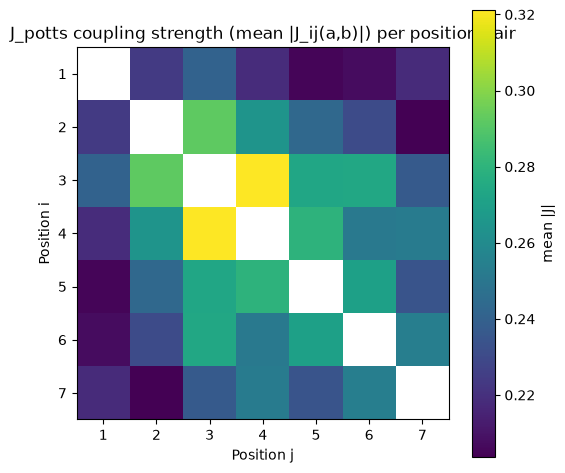

Strongest position pairs by mean |J|: [(3, 4), (2, 3), (4, 5)]


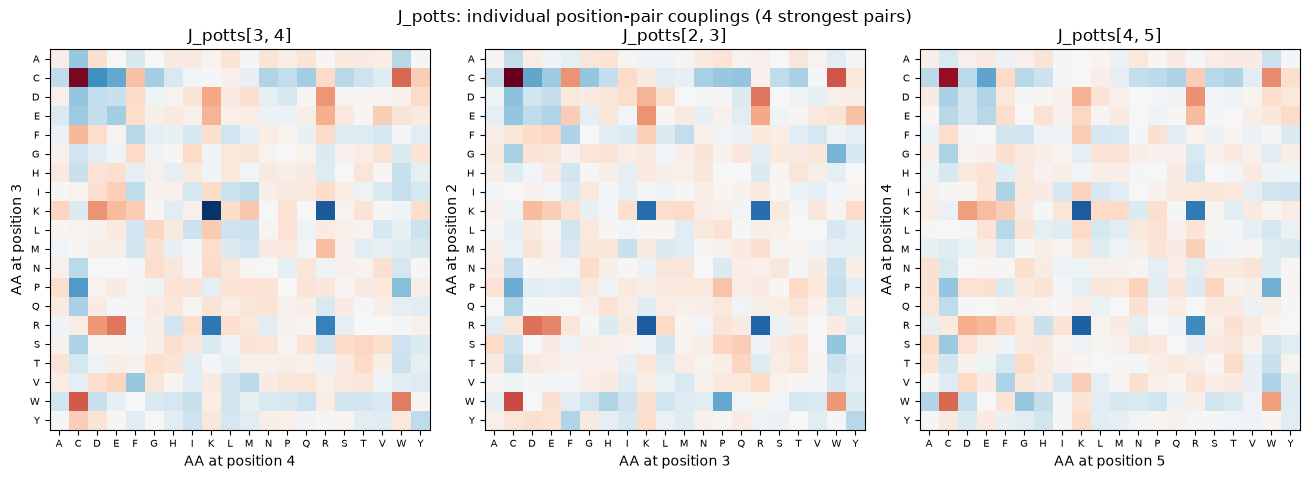

J_potts off-diagonal: mean|J|=0.2474  max|J|=4.1125


In [4]:
J_potts_np = np.array(J_potts)
off_diag_L = ~np.eye(NUM_POSITIONS, dtype=bool)


def coupling_strength(J):
    L = J.shape[0]
    off_diag = ~np.eye(L, dtype=bool)
    strength = np.full((L, L), np.nan)
    strength[off_diag] = np.nanmean(np.abs(J[off_diag]), axis=(1, 2))
    return strength


strength_potts = coupling_strength(J_potts_np)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(strength_potts, cmap="viridis")
ax.set_xlabel("Position j"); ax.set_ylabel("Position i")
ax.set_xticks(range(NUM_POSITIONS)); ax.set_xticklabels(range(1, NUM_POSITIONS + 1))
ax.set_yticks(range(NUM_POSITIONS)); ax.set_yticklabels(range(1, NUM_POSITIONS + 1))
ax.set_title("J_potts coupling strength (mean |J_ij(a,b)|) per position pair")
fig.colorbar(im, ax=ax, label="mean |J|")
fig.tight_layout()
plt.show()

pairs = [(i, j) for i in range(NUM_POSITIONS) for j in range(i + 1, NUM_POSITIONS)]
strongest_pairs = sorted(pairs, key=lambda p: -strength_potts[p])[:3]
print("Strongest position pairs by mean |J|:", [(i + 1, j + 1) for i, j in strongest_pairs])

vmax = max(np.abs(J_potts_np[i, j]).max() for i, j in strongest_pairs)
fig, axes = plt.subplots(1, len(strongest_pairs), figsize=(4.4 * len(strongest_pairs), 4.6))
for ax, (i, j) in zip(axes, strongest_pairs):
    im = ax.imshow(J_potts_np[i, j], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"J_potts[{i + 1}, {j + 1}]")
    ax.set_xticks(range(NUM_AMINO_ACIDS)); ax.set_xticklabels(AA_LABELS, fontsize=7)
    ax.set_yticks(range(NUM_AMINO_ACIDS)); ax.set_yticklabels(AA_LABELS, fontsize=7)
    ax.set_xlabel(f"AA at position {j + 1}"); ax.set_ylabel(f"AA at position {i + 1}")
#fig.colorbar(im, ax=axes, fraction=0.02, pad=0.03, label="J value")
fig.suptitle("J_potts: individual position-pair couplings (4 strongest pairs)")
fig.tight_layout()
plt.show()

print(f"J_potts off-diagonal: mean|J|={np.mean(np.abs(J_potts_np[off_diag_L])):.4f}  "
      f"max|J|={np.max(np.abs(J_potts_np[off_diag_L])):.4f}")


### 2b. GT score distribution across the real AAV9 library

`viab_score_GT_potts = compute_score(F_potts, J_potts)` -- the deterministic F+J score for
every real sequence, no protocol simulation, no noise at all. Same construction as
`AAV9_fitting_protocol.ipynb` section 2b, with the naive GT swapped for the Potts-regression
one.

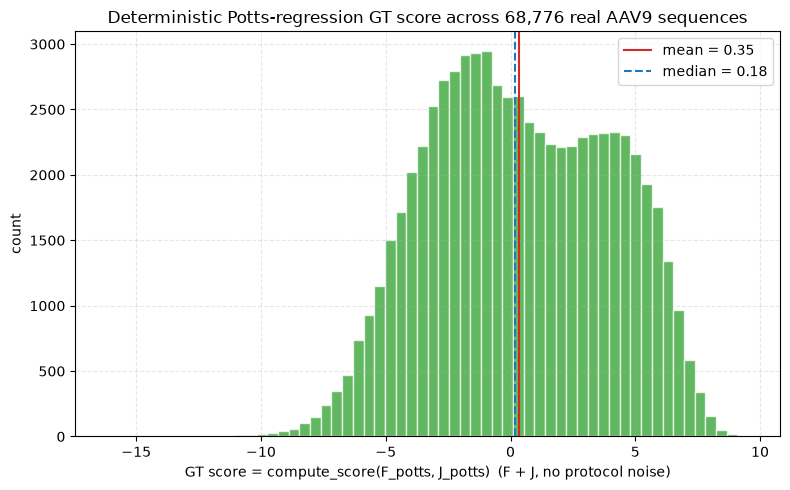

GT score (Potts): min=-16.16  max=9.52  mean=0.35  std=3.62
Pearson r(real aav9 target, GT-potts score) = +0.8888


In [5]:
viab_score_GT_potts = np.asarray(protocol.compute_score(F_potts, J_potts))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(viab_score_GT_potts, bins=60, color="tab:green", alpha=0.75, edgecolor="white")
ax.axvline(viab_score_GT_potts.mean(), color="tab:red", linestyle="-",
           label=f"mean = {viab_score_GT_potts.mean():.2f}")
ax.axvline(np.median(viab_score_GT_potts), color="tab:blue", linestyle="--",
           label=f"median = {np.median(viab_score_GT_potts):.2f}")
ax.set_xlabel("GT score = compute_score(F_potts, J_potts)  (F + J, no protocol noise)")
ax.set_ylabel("count")
ax.set_title(f"Deterministic Potts-regression GT score across {d0:,} real AAV9 sequences")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

r_gt_potts_vs_real = pearson(target, viab_score_GT_potts)
print(f"GT score (Potts): min={viab_score_GT_potts.min():.2f}  max={viab_score_GT_potts.max():.2f}  "
      f"mean={viab_score_GT_potts.mean():.2f}  std={viab_score_GT_potts.std():.2f}")
print(f"Pearson r(real aav9 target, GT-potts score) = {r_gt_potts_vs_real:+.4f}")


### 2c. Percentile recovery: does the Potts GT score rank sequences correctly?

Pearson r (above) measures overall linear correlation, but says nothing about whether the
sequences that actually matter -- the best performers -- are the ones the GT score actually
picks out. This sweeps a grid of percentile thresholds and asks, at each one: of the REAL
top-k% sequences (ranked by measured `target`), what fraction does the deterministic Potts GT
score's own top-k% recover? (`analysisV1.precision_at_k` -- the same top-k recovery metric
used throughout this project for GT-vs-MLP/GT-vs-protocol comparisons, e.g.
`AAV9_profile_model.ipynb`.) The random-guessing baseline at a given percentile is exactly
that percentile itself (e.g. 10% expected by chance at `k_frac=0.10`).

Recovery of the REAL top-k% (by target) within the Potts GT score's own top-k%:


,k,recovery,random_baseline
percentile,,,
1,687,0.072780,0.01
2,1375,0.120727,0.02
5,3438,0.260326,0.05
10,6877,0.449178,0.10
20,13755,0.702944,0.20
30,20632,0.852947,0.30
50,34388,0.908864,0.50
70,48143,0.900172,0.70
100,68776,1.000000,1.00


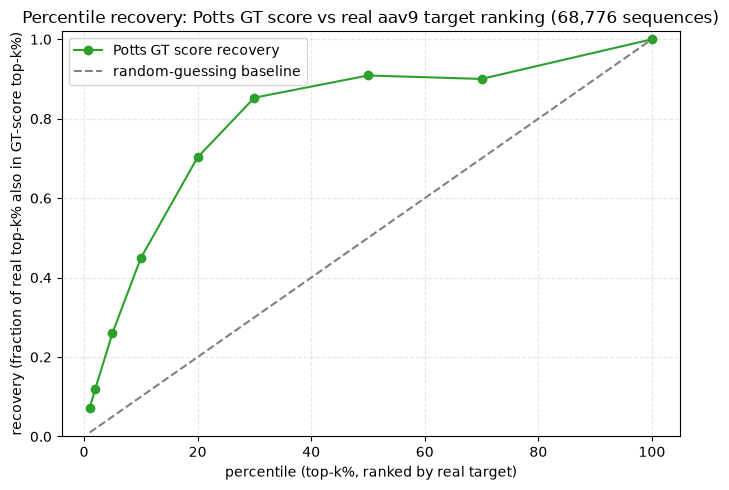

In [6]:
from analysisV1 import precision_at_k, plot_topk_recovery

PERCENTILES = [1, 2, 5, 10, 20, 30, 50, 70, 100]

recovery_rows = []
for pct in PERCENTILES:
    k_frac = pct / 100
    k = max(1, int(d0 * k_frac))
    recovery = precision_at_k(target, viab_score_GT_potts, k_frac=k_frac)
    recovery_rows.append(dict(percentile=pct, k=k, recovery=recovery, random_baseline=k_frac))

recovery_df = pd.DataFrame(recovery_rows).set_index("percentile")
print("Recovery of the REAL top-k% (by target) within the Potts GT score's own top-k%:")
display(recovery_df)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recovery_df.index, recovery_df["recovery"], marker="o", color="tab:green",
        label="Potts GT score recovery")
ax.plot(recovery_df.index, recovery_df["random_baseline"], linestyle="--", color="gray",
        label="random-guessing baseline")
ax.set_xlabel("percentile (top-k%, ranked by real target)")
ax.set_ylabel("recovery (fraction of real top-k% also in GT-score top-k%)")
ax.set_ylim(0, 1.02)
ax.set_title(f"Percentile recovery: Potts GT score vs real aav9 target ranking ({d0:,} sequences)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


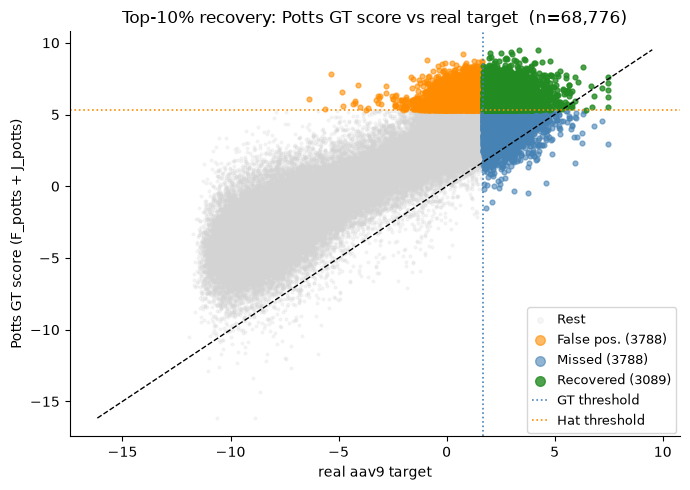

In [7]:
fig = plot_topk_recovery(target, viab_score_GT_potts, k_frac=0.10,
                          xlabel="real aav9 target", ylabel="Potts GT score (F_potts + J_potts)",
                          title=f"Top-10% recovery: Potts GT score vs real target  (n={d0:,})")
plt.show()


## 3. Protocol-simulated log enrichment using this GT

`viability_target1` runs one `loop_DE()` round on `protocol` (seeded with `F_potts`/`J_potts`
above) and returns `target1 = log((lambda2p + eps) / (lambda0p + eps))`, the viability
log-enrichment as estimated from simulated NGS reads only -- same construction as
`AAV9_fitting_protocol.ipynb`'s `viability_target1` (section 3 / 5).

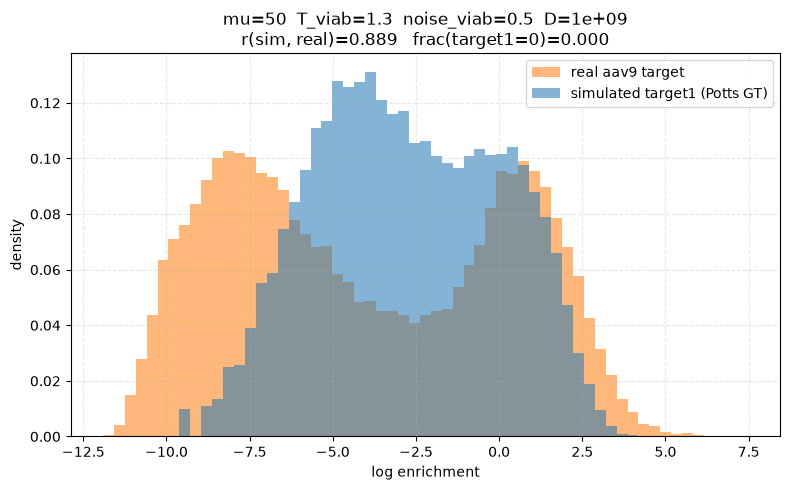

r(simulated target1, real target)     = +0.8886
r(simulated target1, GT-potts score)  = +0.9968
frac(target1 == 0)                    = 0.0000


In [8]:
def viability_target1(protocol, eps=eps):
    """Runs one loop_DE() round and returns target1 = log((lambda2p+eps)/(lambda0p+eps)).
    Resets lambda0 first, since loop_DE() depletes it in place."""
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log((lambda2p + eps) / (lambda0p + eps))


target1_potts = viability_target1(protocol)
r_sim_vs_real = pearson(target1_potts, target)
r_sim_vs_GT   = pearson(target1_potts, viab_score_GT_potts)
frac_zero     = float(np.mean(target1_potts == 0.0))

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(target.min(), target1_potts.min()),
                    max(target.max(), target1_potts.max()), 60)
ax.hist(target,        bins=bins, alpha=0.55, density=True, color="tab:orange", label="real aav9 target")
ax.hist(target1_potts, bins=bins, alpha=0.55, density=True, color="tab:blue",   label="simulated target1 (Potts GT)")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title(f"mu={MU_FIXED:.3g}  T_viab={T_VIAB_FIXED:.3g}  noise_viab={NOISE_VIAB_FIXED:.3g}  D={D_FIXED:.3g}\n"
             f"r(sim, real)={r_sim_vs_real:.3f}   frac(target1=0)={frac_zero:.3f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"r(simulated target1, real target)     = {r_sim_vs_real:+.4f}")
print(f"r(simulated target1, GT-potts score)  = {r_sim_vs_GT:+.4f}")
print(f"frac(target1 == 0)                    = {frac_zero:.4f}")


## 4. Overlay: GT score vs simulated log enrichment

`viab_score_GT_potts` (section 2b, deterministic F+J, no noise) vs `target1_potts` (section 3,
one stochastic `loop_DE()` run at the baseline hyperparameters) -- shows how much the
protocol's noise/`exp(score/T_viab)` transform reshapes the raw Potts-regression GT score into
the simulated log-enrichment distribution.

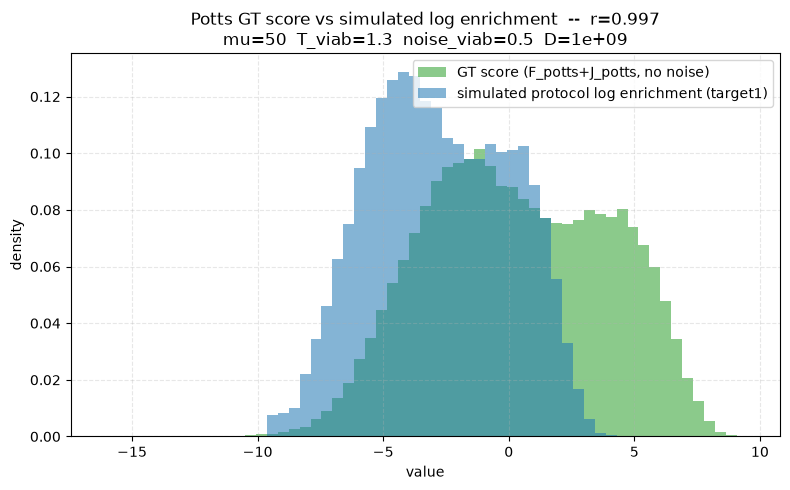

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bins_score = np.linspace(min(viab_score_GT_potts.min(), target1_potts.min()),
                          max(viab_score_GT_potts.max(), target1_potts.max()), 60)
ax.hist(viab_score_GT_potts, bins=bins_score, alpha=0.55, density=True, color="tab:green",
        label="GT score (F_potts+J_potts, no noise)")
ax.hist(target1_potts, bins=bins_score, alpha=0.55, density=True, color="tab:blue",
        label="simulated protocol log enrichment (target1)")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title(f"Potts GT score vs simulated log enrichment  --  r={r_sim_vs_GT:.3f}\n"
             f"mu={MU_FIXED:.3g}  T_viab={T_VIAB_FIXED:.3g}  noise_viab={NOISE_VIAB_FIXED:.3g}  D={D_FIXED:.3g}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 5. Replicate sensitivity -- Potts GT regressed on Production1 vs Production2

Everything above uses `aav9.csv`'s single, already-combined `target` column (68,776
sequences) as the regression target for `F_potts`/`J_potts`. A different real-data source,
`fit4functionaav9.csv` (74,464 rows -- a separate processed dataset of the same designed
AAV9 library, see `log_enrichment_histograms.ipynb`/`new_variant_appearance_analysis.ipynb`
for its provenance; **not** row-aligned with `aav9.csv`, so it is loaded independently below
rather than joined against it), reports the two underlying replicate measurements directly:
`Production1`/`Production2`, two independent DNA constructions of the same designed variant
(`CodonRep1`/`CodonRep2`), each measured once.

Converting each to `log2` (dropping rows where that replicate is not finite-and-positive --
never pseudocounted, same convention as `log_enrichment_histograms.ipynb`) and fitting
`RegressionV1.fit_weights_potts_from_data` separately on each replicate's own valid rows gives
two INDEPENDENT Potts models, `(F_p1, J_p1)` and `(F_p2, J_p2)`, that differ only in which
replicate they saw. Comparing them answers a question the single combined GT above cannot
address: how much does ordinary replicate noise alone move the Potts-regression GT?

The comparison runs on **one uniformly random sample of 1,000,000 variants drawn from the
full 20^7 = 1,280,000,000 sequence space** -- not the library rows either fit saw -- since a
Potts model, unlike the library-only-trained MLPs used elsewhere in this project, assigns a
score to *any* 7-mer via its pairwise structure. Sampling the whole space (same idiom as
`test_for_sweep.ipynb`'s `SCAN_IDX`) asks how much the two replicate-specific models agree
away from the sequences either one was fit on, not just on them.


### 5a. `fit4functionaav9.csv` -- the two replicate targets

In [10]:
df_fit4 = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df_fit4):,} rows, columns: {list(df_fit4.columns)}")

lengths_fit4 = df_fit4["AA"].str.len().unique()
assert len(lengths_fit4) == 1 and int(lengths_fit4[0]) == NUM_POSITIONS, \
    f"expected all-length-{NUM_POSITIONS} sequences, got {lengths_fit4}"

seq_bytes_fit4  = np.frombuffer("".join(df_fit4["AA"]).encode("ascii"), dtype=np.uint8)
seq_matrix_fit4 = lut[seq_bytes_fit4].reshape(len(df_fit4), NUM_POSITIONS)   # `lut` from cell 4

p1_raw = df_fit4["Production1"].to_numpy(dtype=float)
p2_raw = df_fit4["Production2"].to_numpy(dtype=float)
valid_p1 = np.isfinite(p1_raw) & (p1_raw > 0)
valid_p2 = np.isfinite(p2_raw) & (p2_raw > 0)
log2_p1  = np.log2(p1_raw[valid_p1])
log2_p2  = np.log2(p2_raw[valid_p2])

print(f"Production1 valid: {valid_p1.sum():,}/{len(df_fit4):,} ({valid_p1.mean():.1%})")
print(f"Production2 valid: {valid_p2.sum():,}/{len(df_fit4):,} ({valid_p2.mean():.1%})")

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']
Production1 valid: 61,772/74,464 (83.0%)
Production2 valid: 61,641/74,464 (82.8%)


### 5b. Two independent Potts fits -- one per replicate

Same recipe as `AAV9_potts_regression.ipynb` (`RegressionV1.fit_weights_potts_from_data`,
default `lambdas_grid=np.logspace(-1, 2, 30)`, 5-fold CV), applied to each replicate's own
valid rows independently. Two full ridge-CV fits on ~55,000-65,000 rows / 8,541 features each
-- this cell takes several minutes.

In [11]:
import RegressionV1 as R

print("Fitting on Production1 ...")
F_p1, J_p1, rank_p1, info_p1 = R.fit_weights_potts_from_data(
    seq_matrix_fit4[valid_p1], log2_p1, seed=0)

print("\nFitting on Production2 ...")
F_p2, J_p2, rank_p2, info_p2 = R.fit_weights_potts_from_data(
    seq_matrix_fit4[valid_p2], log2_p2, seed=0)

N_FEAT = R.build_potts_features(seq_matrix_fit4[:1]).shape[1]
print(f"\nProduction1 fit: lambda={info_p1['lam']:.3f}  rank={rank_p1}/{N_FEAT}  n_obs={info_p1['n_obs']:,}")
print(f"Production2 fit: lambda={info_p2['lam']:.3f}  rank={rank_p2}/{N_FEAT}  n_obs={info_p2['n_obs']:,}")

Fitting on Production1 ...
lambdas_grid was not defined thus lambdas_grid = [  0.1          0.1268961    0.1610262    0.20433597   0.25929438
   0.32903446   0.41753189   0.52983169   0.67233575   0.85316785
   1.08263673   1.3738238    1.74332882   2.21221629   2.8072162
   3.56224789   4.52035366   5.73615251   7.27895384   9.23670857
  11.72102298  14.87352107  18.87391822  23.9502662   30.39195382
  38.56620421  48.93900918  62.10169419  78.80462816 100.        ]
Design matrix rank: 7715 / 8541 features (61772 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Best lambda: 23.9503

Fitting on Production2 ...
lambdas_grid was not defined thus lambdas_grid = [  0.1          0.1268961    0.1610262    0.20433597   0.25929438
   0.32903446   0.41753189   0.52983169   0.67233575   0.85316785
   1.08263673   1.3738238    1.74332882   2.21221629   2.8072162
   3.56224789   4.52035366   5.73615251   7.27895384   9.23670857
  11.72102298  14.87352107  18.87391822  23.9502662   30.39195382
  38.56620421  48.93900918  62.10169419  78.80462816 100.        ]
Design matrix rank: 7715 / 8541 features (61641 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Best lambda: 23.9503

Production1 fit: lambda=23.950  rank=7715/8541  n_obs=61,772
Production2 fit: lambda=23.950  rank=7715/8541  n_obs=61,641


### 5c. Direct weight comparison

Before looking at scores: how correlated are the raw fitted parameters themselves?
`F_p1`/`F_p2` are `(A, L)` = (20, 7); `J_p1`/`J_p2` are `(L, L, A, A)`, symmetric with an
unused zero diagonal block (`J[i, i]`) -- only the `i < j` off-diagonal blocks carry
information, so those are what gets flattened and compared.

In [12]:
r_F_weights = pearson(np.asarray(F_p1).flatten(), np.asarray(F_p2).flatten())

iu = np.triu_indices(NUM_POSITIONS, k=1)
J_p1_np, J_p2_np = np.asarray(J_p1), np.asarray(J_p2)
r_J_weights = pearson(J_p1_np[iu].flatten(), J_p2_np[iu].flatten())

print(f"r(F_p1, F_p2)            = {r_F_weights:+.4f}   ({np.asarray(F_p1).size} entries)")
print(f"r(J_p1, J_p2), off-diag  = {r_J_weights:+.4f}   ({J_p1_np[iu].size} entries)")

r(F_p1, F_p2)            = +0.9995   (140 entries)
r(J_p1, J_p2), off-diag  = +0.9208   (8400 entries)


### 5d. Score comparison over 1,000,000 randomly sampled variants

`potts_score` -- a standalone version of `Protocol.compute_score`'s formula, so it can score
arbitrary sequences instead of only the ones a `Protocol` was constructed with. Applied to one
fixed sample of 1,000,000 unique 7-mers, drawn uniformly from all `20^7 = 1,280,000,000`
possible variants (same sampling idiom as `test_for_sweep.ipynb`'s `SCAN_IDX`): scores under
`(F_p1, J_p1)`, `(F_p2, J_p2)`, and -- as a third point of reference -- the official
combined-target `(F_potts, J_potts)` already loaded in section 2.

In [13]:
import time
from analysisV1 import topk_recovery

TOTAL_SPACE = NUM_AMINO_ACIDS ** NUM_POSITIONS
SAMPLE_SIZE = 1_000_000
TOPK        = 1000


@jax.jit
def _decode(idx):
    """Linear index -> (n, NUM_POSITIONS) amino-acid index sequence (base-A digits, MSD first)."""
    tmp, digits = idx, []
    for _ in range(NUM_POSITIONS):
        digits.append(tmp % NUM_AMINO_ACIDS)
        tmp = tmp // NUM_AMINO_ACIDS
    return jnp.stack(digits[::-1], axis=1).astype(jnp.int32)


def potts_score(seq, F, J):
    """Same formula as Protocol.compute_score(), standalone so it can score arbitrary
    sequences (not just protocol.sequence)."""
    F, J = jnp.asarray(F, dtype=jnp.float64), jnp.asarray(J, dtype=jnp.float64)
    scores = jnp.sum(F[seq, jnp.arange(NUM_POSITIONS)], axis=1)
    for i in range(NUM_POSITIONS):
        for j in range(i + 1, NUM_POSITIONS):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


_t0 = time.time()
SAMPLE_IDX = np.unique(np.random.default_rng(0).integers(
    0, TOTAL_SPACE, size=SAMPLE_SIZE, dtype=np.int64))
SAMPLE_SEQ = _decode(jnp.asarray(SAMPLE_IDX))

score_p1       = np.asarray(potts_score(SAMPLE_SEQ, F_p1, J_p1))
score_p2       = np.asarray(potts_score(SAMPLE_SEQ, F_p2, J_p2))
score_official = np.asarray(potts_score(SAMPLE_SEQ, F_potts, J_potts))

print(f"{len(SAMPLE_IDX):,} unique sampled variants of {TOTAL_SPACE:,} scored in "
      f"{time.time() - _t0:.1f}s")

999,584 unique sampled variants of 1,280,000,000 scored in 1.4s


### 5e. Comparison stats + plots

Pearson r, top-1000 recovery (exact set intersection -- both rankings live on the same
finite sample, same convention as `test_for_sweep.ipynb`) and top-10% recovery, plus a linear
fit (slope/intercept) and RMSE as a scale/bias check that Pearson r alone would miss. All
three pairs -- P1 vs P2, and each replicate vs the official combined-target GT -- so the
official GT's position relative to the two replicates is visible too.

score_p1:       mean=+0.00  std=3.59
score_p2:       mean=+0.00  std=3.61
score_official: mean=+0.00  std=3.76


,pearson_r,top1000_recovery,top10pct_recovery,slope,intercept,rmse
pair,,,,,,
P1 vs P2,0.9833,0.390,0.8429,0.9871,0.0003,0.6573
P1 vs official,0.9932,0.602,0.9027,1.0397,0.0002,0.4608
P2 vs official,0.9933,0.626,0.9030,1.0358,-0.0000,0.4539


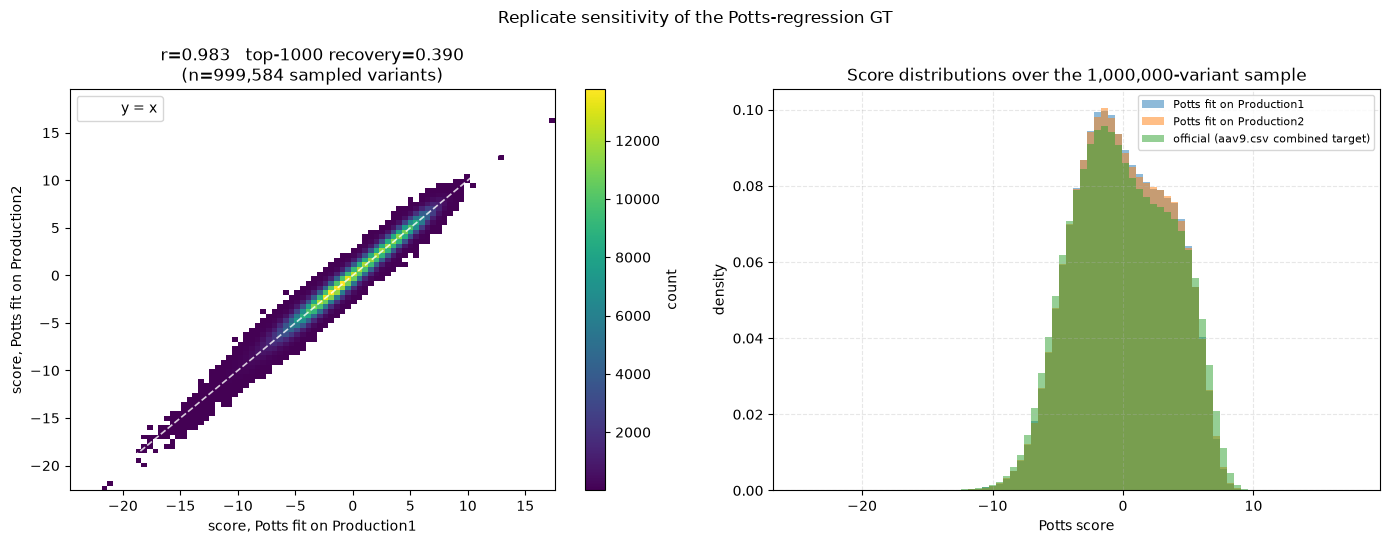

In [14]:
def compare(name_a, s_a, name_b, s_b):
    r      = pearson(s_a, s_b)
    top1k  = topk_recovery(s_a, s_b, k=TOPK)
    top10  = precision_at_k(s_a, s_b, k_frac=0.10)
    slope, intercept = np.polyfit(s_a, s_b, 1)
    rmse   = float(np.sqrt(np.mean((s_a - s_b) ** 2)))
    return dict(pair=f"{name_a} vs {name_b}", pearson_r=r,
                top1000_recovery=top1k, top10pct_recovery=top10,
                slope=slope, intercept=intercept, rmse=rmse)


stats_df = pd.DataFrame([
    compare("P1", score_p1, "P2", score_p2),
    compare("P1", score_p1, "official", score_official),
    compare("P2", score_p2, "official", score_official),
]).set_index("pair").round(4)

print(f"score_p1:       mean={score_p1.mean():+.2f}  std={score_p1.std():.2f}")
print(f"score_p2:       mean={score_p2.mean():+.2f}  std={score_p2.std():.2f}")
print(f"score_official: mean={score_official.mean():+.2f}  std={score_official.std():.2f}")
display(stats_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
h = ax.hist2d(score_p1, score_p2, bins=80, cmap="viridis", cmin=1)
lims = [min(score_p1.min(), score_p2.min()), max(score_p1.max(), score_p2.max())]
ax.plot(lims, lims, "--", color="white", lw=1.2, alpha=0.8, label="y = x")
ax.set_xlabel("score, Potts fit on Production1")
ax.set_ylabel("score, Potts fit on Production2")
ax.set_title(f"r={stats_df.loc['P1 vs P2', 'pearson_r']:.3f}   "
             f"top-{TOPK} recovery={stats_df.loc['P1 vs P2', 'top1000_recovery']:.3f}\n"
             f"(n={len(SAMPLE_IDX):,} sampled variants)")
fig.colorbar(h[3], ax=ax, label="count")
ax.legend()

ax = axes[1]
bins = np.linspace(min(score_p1.min(), score_p2.min(), score_official.min()),
                    max(score_p1.max(), score_p2.max(), score_official.max()), 80)
ax.hist(score_p1,       bins=bins, alpha=0.5, density=True, label="Potts fit on Production1")
ax.hist(score_p2,       bins=bins, alpha=0.5, density=True, label="Potts fit on Production2")
ax.hist(score_official, bins=bins, alpha=0.5, density=True, label="official (aav9.csv combined target)")
ax.set_xlabel("Potts score")
ax.set_ylabel("density")
ax.set_title("Score distributions over the 1,000,000-variant sample")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.3)

fig.suptitle("Replicate sensitivity of the Potts-regression GT")
fig.tight_layout()
plt.show()

## 6. Recovery curves: GT fitted on Production1, scored against Production2

Sections 2c/2d asked how well the deterministic Potts GT score recovers the real `aav9.csv`
`target` ranking. Same two plots here, but:

- the GT is **fitted on `log2(Production1)` only** (`F_p1`/`J_p1` from section 5b), and
- recovery is scored against the **`log2(Production2)`** ranking — the *other* replicate.

Evaluation set: the `valid_both = valid_p1 & valid_p2` rows (both replicates finite &
positive), so the raw `log2(Production1)` ranking is available as a reference curve — the
**replicate ceiling**: how well one replicate's raw, un-modelled measurement predicts the
other's top-k%. If the ridge fit neither adds nor destroys rank information relative to the
noisy replicate it trained on, the `GT(P1)` curve should track that ceiling.

**Caveat**: every `valid_both` row was in `F_p1`/`J_p1`'s fit (`fit_weights_potts_from_data`
uses all rows, no train/test split), so this measures *replicate transfer of the fitted
model*, not held-out generalization. A strict version would refit `F_p1` on a train split of
`valid_p1` and evaluate on the rest — not done here (this notebook's section 5 fits are
already several minutes each).


In [ ]:
valid_both = valid_p1 & valid_p2
n_both     = int(valid_both.sum())

seq_both     = jnp.asarray(seq_matrix_fit4[valid_both])
log2_p1_both = np.log2(p1_raw[valid_both])   # raw replicate 1 measurement (the ceiling reference)
log2_p2_both = np.log2(p2_raw[valid_both])   # the ranking recovery is measured against

gt_p1_score_both = np.asarray(potts_score(seq_both, F_p1, J_p1))   # GT fitted on Production1

print(f"valid in BOTH replicates: {n_both:,} / {len(df_fit4):,}")
print(f"r(GT(P1) score, log2 P2)        = {pearson(gt_p1_score_both, log2_p2_both):+.4f}")
print(f"r(raw log2 P1, log2 P2)  [ceil] = {pearson(log2_p1_both,     log2_p2_both):+.4f}")

PERCENTILES = [1, 2, 5, 10, 20, 30, 50, 70, 100]
rec_rows = []
for pct in PERCENTILES:
    kf = pct / 100
    rec_rows.append(dict(
        percentile      = pct,
        gt_p1_recovery  = precision_at_k(log2_p2_both, gt_p1_score_both, k_frac=kf),
        raw_p1_ceiling  = precision_at_k(log2_p2_both, log2_p1_both,     k_frac=kf),
        random_baseline = kf,
    ))
rec_p1p2_df = pd.DataFrame(rec_rows).set_index("percentile")
print("\nRecovery of the Production2 top-k% (by log2 P2):")
display(rec_p1p2_df.round(3))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(rec_p1p2_df.index, rec_p1p2_df["gt_p1_recovery"], marker="o", color="tab:green",
        label="Potts GT fitted on Production1 (score)")
ax.plot(rec_p1p2_df.index, rec_p1p2_df["raw_p1_ceiling"], marker="s", color="tab:orange",
        label="raw log2(Production1)  [replicate ceiling]")
ax.plot(rec_p1p2_df.index, rec_p1p2_df["random_baseline"], linestyle="--", color="gray",
        label="random-guessing baseline")
ax.set_xlabel("percentile (top-k%, ranked by log2 Production2)")
ax.set_ylabel("recovery (fraction of Production2 top-k% also in predictor's top-k%)")
ax.set_ylim(0, 1.02)
ax.set_title(f"Percentile recovery vs Production2 ranking  (n={n_both:,} valid-in-both)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


In [ ]:
fig = plot_topk_recovery(
    log2_p2_both, gt_p1_score_both, k_frac=0.10,
    xlabel="real log2(Production2)",
    ylabel="Potts GT score, fitted on Production1 (F_p1 + J_p1)",
    title=f"Top-10% recovery: Production1-fitted GT score vs Production2  (n={n_both:,})",
)
plt.show()
